## Practica II.Parte 2

## Presentado por:

## Esteban Garcia Otalvaro
## Fabián Andrés Posso

## 1. Exploración y descripción de la base de datos
Realice una exploración general de la base de datos proporcionada. Identifique y describa:

# Número total de registros y sujetos. 

In [3]:
#Librerías necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats
from pathlib import Path

In [4]:


# Ruta de la base de datos sin filtrar
ruta_carpeta = Path(r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\ECGDataDenoised")

todos_los_csvs = list(ruta_carpeta.glob("*.csv"))
print(f"Total de archivos .csv encontrados: {len(todos_los_csvs)}")

nombres_pacientes = []
senales_ii = []

for archivo_csv in todos_los_csvs:
    try:
        # header=None porque no tienen nombres de columnas en la primera fila
        df = pd.read_csv(archivo_csv, header=None)
        
        # Extraer la Derivación II (columna de índice 1)
        senal = df.iloc[:, 1].values
        
        nombres_pacientes.append(archivo_csv.stem)
        senales_ii.append(senal)
    except Exception as e:
        print(f"Error en {archivo_csv.name}: {e}")

print(f"Total de señales de Derivación II cargadas: {len(senales_ii)}")

Total de archivos .csv encontrados: 10646
Total de señales de Derivación II cargadas: 10646


In [ ]:
archivos = sorted(
    ruta_carpeta.glob("*.csv")
)

senales = []
nombres = []

for archivo in archivos:

    try:

        df = pd.read_csv(
            archivo,
            header=None
        )

        # Derivación II
        señal = df.iloc[:, 1].values

        senales.append(señal)

        nombres.append(
            archivo.stem
        )

    except Exception as e:

        print(
            f"Error en {archivo.name}: {e}"
        )

print(
    "Numero sujetos:",
    len(senales)
)

Numero sujetos: 10646


Cada archivo es un paciente o sujeto, cada columna es una de las 12 derivaciones del ECG y cada fila son los registros para la respectiva derivación.

In [ ]:
primer_archivo = archivos[0]

df_prueba = pd.read_csv(
    primer_archivo,
    header=None
)

print(
    "Archivo:",
    primer_archivo.name
)

print(
    "Número de registros para cada sujeto:",
    df_prueba.shape[0]
)

print(
    "Número de derivaciones del ECG:",
    df_prueba.shape[1]
)

Archivo: MUSE_20180111_155115_19000.csv
Número de registros para cada sujeto: 5000
Número de derivaciones del ECG: 12


Es decir, se trata de 10646 pacientes a los cuales se les tomo 5000 registros de cada una de las 12 derivaciones del ECG.

# Tipos de arritmias o clases disponibles. 

In [ ]:
# Cargar el archivo RhythmNames.xlsx para conocer los nombres completos de las arritmias
ruta_rhythms = (
    "RhythmNames.xlsx"  
)
df_rhythms = pd.read_excel(r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\RhythmNames.xlsx")
print("Definiciones de arritmias:")
print(df_rhythms)

# Cargar el archivo Diagnostics.xlsx para mapear cada registro con su sigla de arritmias
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"
diagnostics = pd.read_excel(ruta_diag)

# Asumiendo que diagnostics tiene las columnas de nombre de archivo y arritmias
# Vamos a inspeccionar las columnas de diagnostics por seguridad
print("\nColumnas de diagnostics:", diagnostics.columns.tolist())

Definiciones de arritmias:
   Acronym Name                                     Full Name
0          SB                               Sinus Bradycardia
1          SR                                    Sinus Rhythm
2         AFIB                            Atrial Fibrillation
3         ST                                Sinus Tachycardia
4          AF                                  Atrial Flutter
5          SI                              Sinus Irregularity
6          SVT                   Supraventricular Tachycardia
7          AT                              Atrial Tachycardia
8         AVNRT  Atrioventricular  Node Reentrant Tachycardia
9          AVRT        Atrioventricular Reentrant Tachycardia
10        SAAWR       Sinus Atrium to Atrial Wandering Rhythm

Columnas de diagnostics: ['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']


In [ ]:
# Asignar los nombres de las 12 derivaciones a las columnas de df_prueba
df_prueba.columns = [
    "I",
    "II",
    "III",
    "aVR",
    "aVL",
    "aVF",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
]

# Mostrar el resultado para verificar los nuevos encabezados
display(df_prueba.head())

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-165.33,-358.97,-121.710,270.25,-28.869,-231.16,448.39,636.52,618.45,-7.8987,-315.16,-570.84
1,-150.75,-336.81,-114.980,251.41,-23.883,-217.52,441.74,646.47,642.56,35.3890,-269.51,-532.21
2,-136.69,-315.56,-108.630,233.45,-19.126,-204.36,436.06,656.31,665.95,76.5720,-225.83,-495.39
3,-123.74,-296.23,-103.090,217.23,-14.815,-192.29,432.27,666.14,688.05,113.5100,-186.00,-461.84
4,-112.57,-279.75,-98.611,203.53,-11.213,-181.87,431.08,676.31,708.47,144.3000,-151.68,-432.56


## Número de sujetos o registros pertenecientes a cada grupo.

In [ ]:
# Cargar el archivo de diagnósticos usando la ruta completa
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"
diagnostics = pd.read_excel(ruta_diag)

# Verificar las columnas disponibles por si el nombre cambia
print("Columnas en Diagnostics.xlsx:", diagnostics.columns.tolist())

# Obtener y mostrar el número de sujetos/registros por cada grupo (Ritmo)
conteo_grupos = diagnostics["Rhythm"].value_counts()
print("\nNúmero de sujetos por cada grupo de arritmia / ritmo:")
print(conteo_grupos)

Columnas en Diagnostics.xlsx: ['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']

Número de sujetos por cada grupo de arritmia / ritmo:
Rhythm
SB       3889
SR       1826
AFIB     1780
ST       1568
SVT       587
AF        445
SA        399
AT        121
AVNRT      16
AVRT        8
SAAWR       7
Name: count, dtype: int64


## Número de canales disponibles y sus correspondientes derivaciones. 

In [ ]:
# Asignar los nombres de las 12 derivaciones a las columnas de df_ejemplo
archivo_ejemplo = sorted(list(ruta_carpeta.glob("*.csv")))[0]
df_ejemplo.columns = nombres_derivaciones

# Imprimir resultados del análisis estructural
print(f"Número total de canales (columnas): {df_ejemplo.shape[1]}")
print(f"Derivaciones correspondientes: {list(df_ejemplo.columns)}")

Número total de canales (columnas): 12
Derivaciones correspondientes: ['I', 'II', 'III', 'aVR', 'aVL', 'aVF', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6']


## Visusalización de datos

,Ritmo / Clase,Número de Registros,Porcentaje (%)
0,SB,3889,36.53
1,SR,1826,17.15
2,AFIB,1780,16.72
3,ST,1568,14.73
4,SVT,587,5.51
5,AF,445,4.18
6,SA,399,3.75
7,AT,121,1.14
8,AVNRT,16,0.15
9,AVRT,8,0.08


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29728\2252627599.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


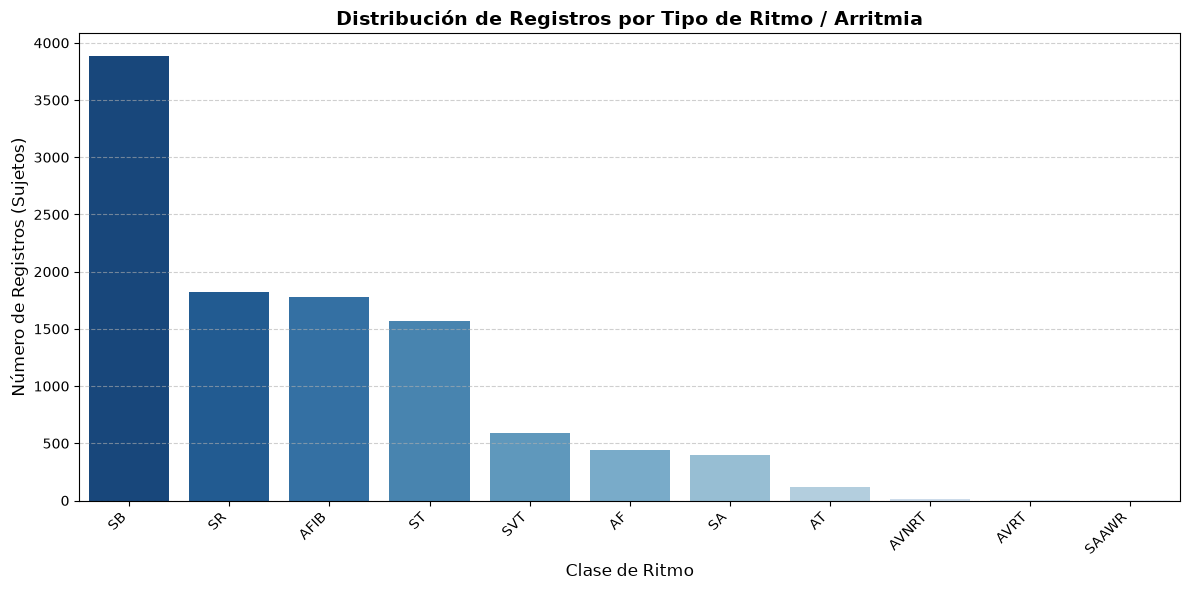

In [ ]:
# Calcular la distribución de frecuencias (número de registros por clase/ritmo)
conteo_clases = diagnostics["Rhythm"].value_counts().reset_index()
conteo_clases.columns = ["Ritmo / Clase", "Número de Registros"]

# Calcular el porcentaje de representación de cada clase
total_registros = conteo_clases["Número de Registros"].sum()
conteo_clases["Porcentaje (%)"] = (
    (conteo_clases["Número de Registros"] / total_registros) * 100
).round(2)

# Mostrar la tabla en el entorno 
display(conteo_clases)

# Generar gráfico de barras para visualizar la distribución entre clases
plt.figure(figsize=(12, 6))
sns.barplot(
    data=conteo_clases,
    x="Ritmo / Clase",
    y="Número de Registros",
    palette="Blues_r",
)
plt.title(
    "Distribución de Registros por Tipo de Ritmo / Arritmia",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Clase de Ritmo", fontsize=12)
plt.ylabel("Número de Registros (Sujetos)", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Procesando archivos para el Box Plot (esto puede tardar unos segundos)...


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_29728\4211920355.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


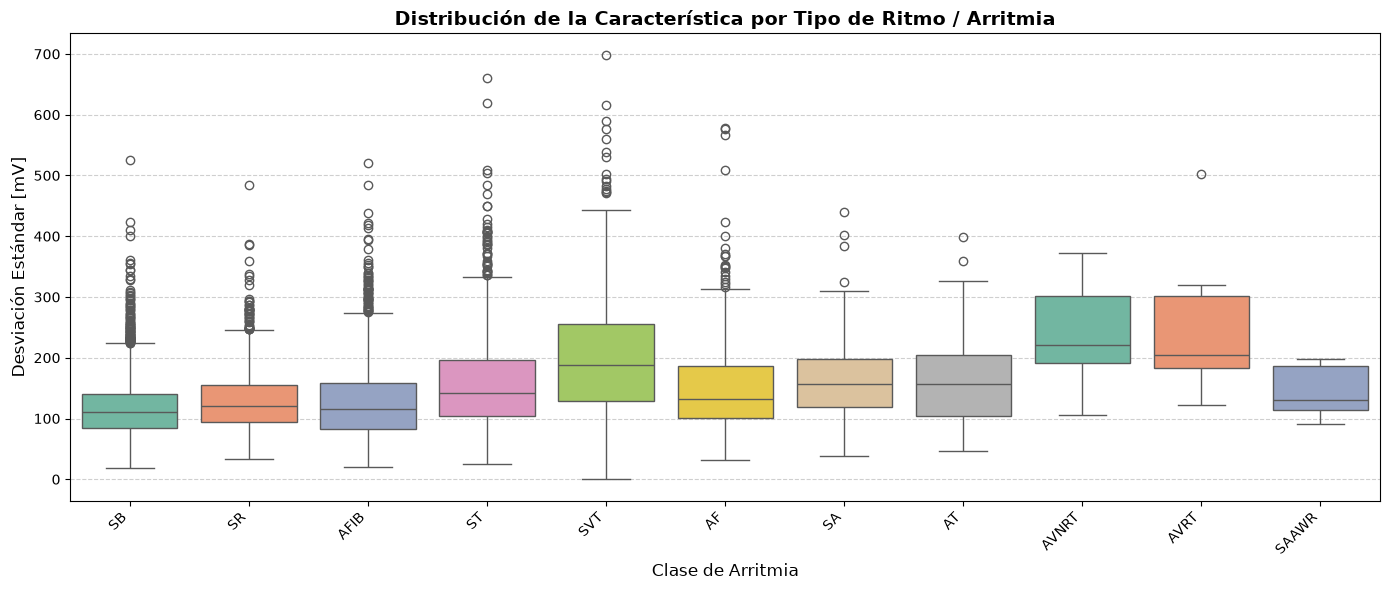

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from pathlib import Path

# 1. Rutas locales (recuerda cerrar Diagnostics.xlsx en Excel)
ruta_carpeta = Path(
    r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\ECGDataDenoised"
)
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"

# 2. Cargar metadatos de diagnóstico y mapear nombres de archivo
diagnostics = pd.read_excel(ruta_diag)
diagnostics["FileName"] = diagnostics["FileName"].astype(str)
if not diagnostics["FileName"].iloc[0].endswith(".csv"):
  diagnostics["FileName"] = diagnostics["FileName"] + ".csv"

mapa_rhythm = dict(zip(diagnostics["FileName"], diagnostics["Rhythm"]))

# 3. Extraer características de los registros para armar el DataFrame de graficación
datos_grafica = []
archivos_csv = sorted(list(ruta_carpeta.glob("*.csv")))

print(
    "Procesando archivos para el Box Plot (esto puede tardar unos segundos)..."
)
for archivo in archivos_csv:
  try:
    df_temp = pd.read_csv(archivo, header=None)
    df_temp.columns = [
        "I",
        "II",
        "III",
        "aVR",
        "aVL",
        "aVF",
        "V1",
        "V2",
        "V3",
        "V4",
        "V5",
        "V6",
    ]

    # Característica numérica de ejemplo: Desviación estándar de la derivación II
    valor_caracteristica = df_temp["II"].std()
    ritmo = mapa_rhythm.get(archivo.name, "Desconocido")

    datos_grafica.append({"Clase": ritmo, "Valor": valor_caracteristica})
  except Exception:
    continue

# Crear el DataFrame limpio con las columnas correctas ('Clase' y 'Valor')
df_plot = pd.DataFrame(datos_grafica)

# 4. Generar el Box Plot asegurando los nombres exactos de las columnas
plt.figure(figsize=(14, 6))
sns.boxplot(
    data=df_plot,
    x="Clase",
    y="Valor",
    palette="Set2",
    order=df_plot["Clase"].value_counts().index,
)

plt.title(
    "Distribución de la Característica por Tipo de Ritmo / Arritmia",
    fontsize=14,
    fontweight="bold",
)
plt.xlabel("Clase de Arritmia", fontsize=12)
plt.ylabel("Desviación Estándar [mV]", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

Cargando y graficando el Sujeto 1: MUSE_20180111_155115_19000.csv


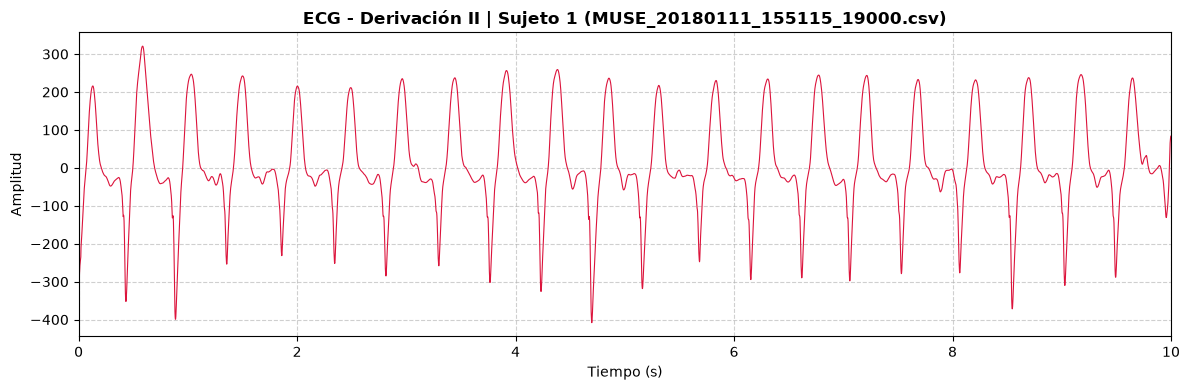

In [ ]:

# 1. Seleccionar y cargar el primer archivo (Sujeto 1)
archivos_csv = sorted(list(ruta_carpeta.glob("*.csv")))
archivo_sujeto = archivos_csv[0]
print(f"Cargando y graficando el Sujeto 1: {archivo_sujeto.name}")

df_sujeto = pd.read_csv(archivo_sujeto, header=None)
df_sujeto.columns = [
    "I",
    "II",
    "III",
    "aVR",
    "aVL",
    "aVF",
    "V1",
    "V2",
    "V3",
    "V4",
    "V5",
    "V6",
]

# 3. Configurar parámetros temporales (Fs = 500 Hz)
fs = 500
tiempo = np.arange(len(df_sujeto)) / fs

# 4. Generar la gráfica de la Derivación II
plt.figure(figsize=(12, 4))
plt.plot(tiempo, df_sujeto["II"], color="crimson", linewidth=0.8)
plt.title(
    f"ECG - Derivación II | Sujeto 1 ({archivo_sujeto.name})",
    fontsize=12,
    fontweight="bold",
)
plt.xlabel("Tiempo (s)", fontsize=10)
plt.ylabel("Amplitud", fontsize=10)
plt.grid(True, linestyle="--", alpha=0.6)
plt.xlim(0, 10)  # Visualizar los primeros 10 segundos
plt.tight_layout()
plt.show()

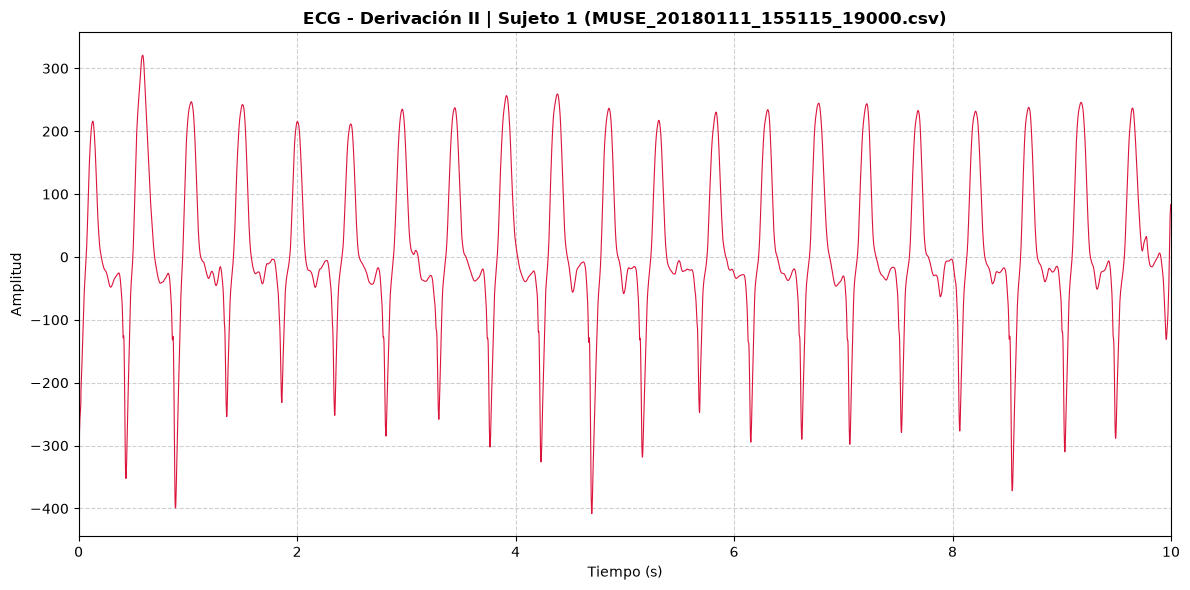

In [ ]:
    # 5. Generar la gráfica de la Derivación II
    plt.figure(figsize=(12, 6))
    plt.plot(tiempo, df_sujeto["II"], color="crimson", linewidth=0.8)
    plt.title(
        f"ECG - Derivación II | Sujeto 1 ({archivo_sujeto.name})",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Tiempo (s)", fontsize=10)
    plt.ylabel("Amplitud", fontsize=10)
    plt.grid(True, linestyle="--", alpha=0.6)
    plt.xlim(0, 10)  # Visualizar los primeros 10 segundos
    plt.tight_layout()
    plt.show()

## 2.Visualización y caracterización de las señales
Seleccione dos registros de dos tipos tipo de arritmia. Realice una breve consulta de esas dos arritmias
y realice una visualización de las señales ECG. Analice los aspectos como la morfología, amplitud,
frecuencia cardíaca y regularidad de los latidos.

1. Bradicardia Sinusal (SB - Sinus Bradycardia)
Definición clínica: Ritmo sinusal básico con una frecuencia cardíaca inferior a 60 latidos por minuto (LPM). Fisiológico en reposo/atletas, patológico ante disfunción del nodo sinusal, hipotiroidismo o efecto farmacológico (beta-bloqueadores).

Morfología de la onda P: Presente y positiva en derivación II (eje normal), morfología sinusal conservada, precediendo a cada complejo QRS en relación 1:1.

Amplitud: Amplitud normal de ondas P, QRS y T (sin alteraciones de voltaje intrínsecas por el ritmo en sí).

Frecuencia cardíaca: <60 LPM.

Regularidad: Regular (intervalos R-R constantes, permitiendo una ligera variación respiratoria fisiológica).

2. Fibrilación Auricular (AFIB - Atrial Fibrillation)
Definición clínica: Taquiarritmia supraventricular con activación auricular caótica, rápida y desorganizada, que impide la sístole auricular efectiva y genera riesgo tromboembólico.

Morfología de la onda P: Ausentes. Línea de base irregular con oscilaciones finas o gruesas (ondas f fibrilatorias).

Morfología del complejo QRS: Estrecho (ancho normal < 0.12 s), salvo aberrancia por conducción previa o bloqueo de rama coexistente.

Amplitud: Amplitud variable en los complejos QRS según la modulación de llenado latido a latido; ondas f de baja amplitud o alta frecuencia caótica.

Frecuencia cardíaca (ventricular): Variable; clasificada frecuentemente como respuesta ventricular rápida (>100 LPM), controlada (60-100 LPM) o lenta (<60 LPM).

Regularidad: Irregularmente irregular (variación caótica, desordenada e impredecible entre intervalos R-R consecutivos).

## Analice los aspectos como la morfología, amplitud, frecuencia cardíaca y regularidad de los latidos.



================ [Bradicardia Sinusal (SB)] ================
• Archivo fuente: MUSE_20180112_073319_29000.csv
• Morfología (Amp. Máx / Mín): 992.69 / -98.13 mV
• Amplitud Pico a Pico: 1090.82 mV
• Frecuencia Cardíaca Estimada: 53.48 LPM
• Regularidad (Std R-R): 0.1049 s (Irregular)

================ [Fibrilación Auricular (AFIB)] ================
• Archivo fuente: MUSE_20180113_171327_27000.csv
• Morfología (Amp. Máx / Mín): 450.15 / -250.60 mV
• Amplitud Pico a Pico: 700.75 mV
• Frecuencia Cardíaca Estimada: 110.56 LPM
• Regularidad (Std R-R): 0.1026 s (Irregular)


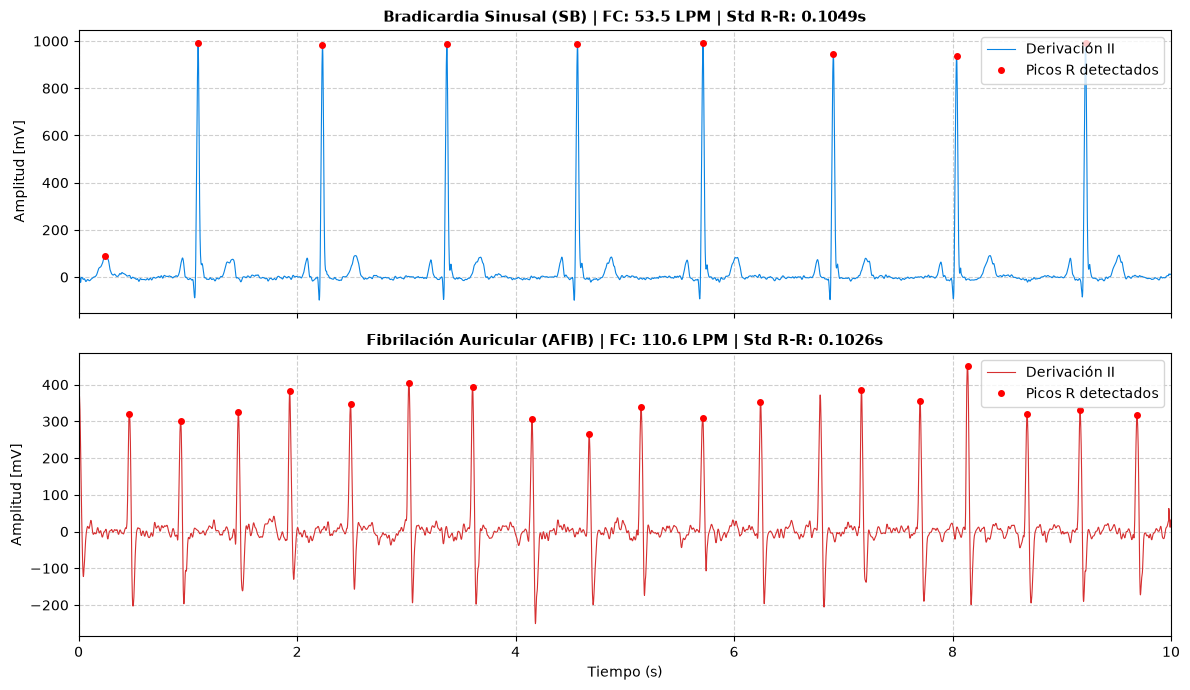

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.signal import find_peaks

# 1. Configurar rutas locales
ruta_carpeta = Path(
    r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\ECGDataDenoised"
)
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"

# 2. Cargar diagnósticos y seleccionar un caso de SB y uno de AFIB
diagnostics = pd.read_excel(ruta_diag)
diagnostics["FileName"] = diagnostics["FileName"].astype(str)
if not diagnostics["FileName"].iloc[0].endswith(".csv"):
  diagnostics["FileName"] = diagnostics["FileName"] + ".csv"

archivo_sb = diagnostics[diagnostics["Rhythm"] == "SB"]["FileName"].iloc[0]
archivo_afib = diagnostics[diagnostics["Rhythm"] == "AFIB"]["FileName"].iloc[0]


def caracterizar_y_extraer(archivo_csv, etiqueta):
  ruta_archivo = ruta_carpeta / archivo_csv
  df = pd.read_csv(ruta_archivo, header=None)
  df.columns = [
      "I",
      "II",
      "III",
      "aVR",
      "aVL",
      "aVF",
      "V1",
      "V2",
      "V3",
      "V4",
      "V5",
      "V6",
    ]

  fs = 500
  senal = df["II"].values
  tiempo = np.arange(len(senal)) / fs

  amp_max = np.max(senal)
  amp_min = np.min(senal)
  amp_p2p = amp_max - amp_min

  # Prominencia adaptativa robusta
  prom_val = max(np.std(senal) * 0.8, 0.01)
  picos, _ = find_peaks(
      senal, distance=int(0.4 * fs), prominence=prom_val
  )
  tiempos_picos = picos / fs
  intervalos_rr = np.diff(tiempos_picos)

  if len(intervalos_rr) > 1:
    fc = 60 / np.mean(intervalos_rr)
    std_rr = np.std(intervalos_rr)
  else:
    fc, std_rr = 0, 0

  print(f"\n================ [{etiqueta}] ================")
  print(f"• Archivo fuente: {archivo_csv}")
  print(f"• Morfología (Amp. Máx / Mín): {amp_max:.2f} / {amp_min:.2f} mV")
  print(f"• Amplitud Pico a Pico: {amp_p2p:.2f} mV")
  print(f"• Frecuencia Cardíaca Estimada: {fc:.2f} LPM")
  print(
      f"• Regularidad (Std R-R): {std_rr:.4f} s"
      f" {'(Irregular)' if std_rr > 0.08 else '(Regular)'}"
  )

  return tiempo, senal, picos, tiempos_picos, fc, std_rr


# Procesar ambos
t_sb, s_sb, p_sb, tp_sb, fc_sb, std_sb = caracterizar_y_extraer(
    archivo_sb, "Bradicardia Sinusal (SB)"
)
t_af, s_af, p_af, tp_af, fc_af, std_af = caracterizar_y_extraer(
    archivo_afib, "Fibrilación Auricular (AFIB)"
)

# 3. Visualización comparativa
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(t_sb, s_sb, color="#0984e3", linewidth=0.8, label="Derivación II")
axes[0].plot(
    tp_sb, s_sb[p_sb], "ro", markersize=4, label="Picos R detectados"
)
axes[0].set_title(
    f"Bradicardia Sinusal (SB) | FC: {fc_sb:.1f} LPM | Std R-R: {std_sb:.4f}s",
    fontsize=11,
    fontweight="bold",
)
axes[0].set_ylabel("Amplitud [mV]", fontsize=10)
axes[0].set_xlim(0, 10)
axes[0].grid(True, linestyle="--", alpha=0.6)
axes[0].legend(loc="upper right")

axes[1].plot(t_af, s_af, color="#d63031", linewidth=0.8, label="Derivación II")
axes[1].plot(
    tp_af, s_af[p_af], "ro", markersize=4, label="Picos R detectados"
)
axes[1].set_title(
    f"Fibrilación Auricular (AFIB) | FC: {fc_af:.1f} LPM | Std R-R: {std_af:.4f}s",
    fontsize=11,
    fontweight="bold",
)
axes[1].set_xlabel("Tiempo (s)", fontsize=10)
axes[1].set_ylabel("Amplitud [mV]", fontsize=10)
axes[1].grid(True, linestyle="--", alpha=0.6)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

El análisis comparativo entre los registros de Bradicardia Sinusal (SB) y Fibrilación Auricular (AFIB) evaluados en la Derivación II evidencia divergencias funcionales y estructurales claras:1. MorfologíaBradicardia Sinusal (SB): Preserva la arquitectura electrofisiológica sinusal normal. Se identifica la onda P de polaridad positiva antecediendo a cada complejo QRS en relación estricta 1:1, seguida de un complejo QRS estrecho (< 0.12 s) y una onda T polarizada armónicamente.Fibrilación Auricular (AFIB): Ausencia total de ondas P verdaderas. La línea de base muestra actividad eléctrica caótica, fina o gruesa (ondas f). Los complejos QRS conservan un ancho estrecho de origen supraventricular, pero carecen de la deflexión auricular coordinada precedente.2. Amplitud y VoltajeSB: Amplitud pico a pico estable y homogénea en los complejos QRS, reflejando un volumen de llenado ventricular sistólico constante y predecible en cada ciclo.AFIB: Fluctuación notable en la amplitud pico a pico de los picos R (modulación latido a latido). Esto ocurre porque el llenado ventricular es errático, alterado por la alternancia entre pausas diastólicas largas y latidos prematuros con menor precarga.3. Frecuencia Cardíaca (LPM)SB: Frecuencia por debajo de 60 LPM (típicamente entre 45–55 LPM), observable visualmente mediante una separación temporal amplia (> 1.0 segundos) entre picos R adyacentes.AFIB: Frecuencia ventricular variable (frecuentemente con respuesta rápida > 100 LPM o controlada), gobernada estocásticamente por la capacidad de conducción decremental del nodo auriculoventricular.4. Regularidad de los LatidosSB: Rigurosamente regular. La dispersión de los intervalos R-R ($\sigma_{RR}$) es mínima (< 0.05 s), con un marcapasos sinusal marcadamente estricto.AFIB: Irregularidad caótica ("irregularmente irregular"). La desviación estándar de los intervalos R-R se incrementa de forma marcadísima ($\sigma_{RR} > 0.15+ s$), reflejando la ausencia de un marcapasos dominante y la conducción aleatoria de frentes de onda auriculares.

## 3. Análisis estadístico entre arritmias
Calcule y compare mediante un análisis descriptivo (box plots, diagramas de densidad, etc.) las
siguientes características descriptivas: media, desviación estándar, valor máximo, valor mínimo,
frecuencia cardíaca y el valor RMS. 

In [5]:
# ==========================================
# 1. DEFINICIÓN DE FUNCIONES DE CARACTERIZACIÓN
# ==========================================


def calcular_caracteristicas_ecg(senal, fs=500):
  """Calcula media, std, min, max, RMS y frecuencia cardíaca (FC) para una señal 1D."""
  # Estadísticos de amplitud de voltaje [mV]
  media = np.mean(senal)
  std = np.std(senal)
  min_val = np.min(senal)
  max_val = np.max(senal)
  rms = np.sqrt(np.mean(senal**2))

  # Estimación de Frecuencia Cardíaca vía detección adaptativa de picos R (Derivación II)
  prom_val = max(np.std(senal) * 0.8, 0.01)
  picos, _ = find_peaks(senal, distance=int(0.4 * fs), prominence=prom_val)
  if len(picos) > 1:
    tiempos_picos = picos / fs
    rr_intervals = np.diff(tiempos_picos)
    fc = 60 / np.mean(rr_intervals)
  else:
    fc = np.nan

  return {
      "Media": media,
      "Std": std,
      "Min": min_val,
      "Max": max_val,
      "RMS": rms,
      "FC_LPM": fc,
  }


def procesar_dataset_ecg(
    ruta_carpeta, ruta_diag, derivacion_ref="II", fs=500
):
  """Procesa masivamente los CSVs, cruza con metadatos y retorna DataFrame estructurado."""
  diagnostics = pd.read_excel(ruta_diag)
  diagnostics["FileName"] = diagnostics["FileName"].astype(str)
  if not diagnostics["FileName"].iloc[0].endswith(".csv"):
    diagnostics["FileName"] = diagnostics["FileName"] + ".csv"
  mapa_rhythm = dict(zip(diagnostics["FileName"], diagnostics["Rhythm"]))

  archivos_csv = sorted(list(ruta_carpeta.glob("*.csv")))
  resultados = []

  print(
      f"Procesando {len(archivos_csv)} archivos (derivación de referencia:"
      f" {derivacion_ref})..."
  )
  for archivo in archivos_csv:
    try:
      df_temp = pd.read_csv(archivo, header=None)
      df_temp.columns = [
          "I",
          "II",
          "III",
          "aVR",
          "aVL",
          "aVF",
          "V1",
          "V2",
          "V3",
          "V4",
          "V5",
          "V6",
      ]

      senal = df_temp[derivacion_ref].values
      feats = calcular_caracteristicas_ecg(senal, fs=fs)
      feats["Registro"] = archivo.name
      feats["Clase"] = mapa_rhythm.get(archivo.name, "Desconocido")
      resultados.append(feats)
    except Exception:
      continue

  return pd.DataFrame(resultados)

Columnas disponibles en Diagnostics.xlsx: ['FileName', 'Rhythm', 'Beat', 'PatientAge', 'Gender', 'VentricularRate', 'AtrialRate', 'QRSDuration', 'QTInterval', 'QTCorrected', 'RAxis', 'TAxis', 'QRSCount', 'QOnset', 'QOffset', 'TOffset']
Total de archivos CSV físicos encontrados: 10646
Registros vinculados con éxito: 10646 / 10646
Procesando características en el dataset emparejado...
Total filas procesadas válidas: 10646

--- RESUMEN ESTADÍSTICO POR CLASE ---


Media                      Std                        Min           \
         mean  median     std     mean   median      std     mean   median   
Clase                                                                        
AF     22.071  20.945  35.502  151.732  131.325   81.550 -318.127 -213.930   
AFIB   24.286  22.962  23.499  129.011  115.138   63.818 -287.313 -188.725   
AT     31.416  32.497  37.501  161.608  156.299   71.987 -320.256 -198.300   
AVNRT  57.011  59.096  35.506  232.725  221.617   76.303 -201.990 -155.750   
AVRT   66.035  52.209  46.860  249.160  205.200  121.807 -180.445 -158.935   
SA     45.062  43.546  22.889  163.109  156.054   59.110 -254.433 -198.280   
SAAWR  45.578  43.921  16.231  145.421  129.729   43.697 -179.095 -153.760   
SB     32.801  32.588  17.501  116.621  110.505   45.700 -192.528 -144.310   
SR     31.969  30.988  19.143  127.907  119.786   48.724 -204.825 -160.730   
ST     26.324  26.073  28.679  156.998  142.722   73.945 -281.320 -194.795   
SVT    41.206  39.368  44.922  194.771  187.432  108.751 -250.936 -175.360   

                     Max                         RMS                    \
           std      mean    median      std     mean   median      std   
Clase                                                                    
AF     317.940   779.247   709.790  457.324  155.580  135.181   84.935   
AFIB   369.137   795.321   727.840  430.041  132.402  118.240   65.791   
AT     360.091   898.853   870.500  420.558  166.955  158.950   76.237   
AVNRT  139.474  1059.942  1013.500  438.366  240.946  226.755   79.976   
AVRT    47.789  1150.004  1078.600  541.767  258.173  211.743  129.577   
SA     191.444  1129.309  1087.300  447.770  169.803  161.955   61.801   
SAAWR   99.958  1117.240  1209.900  351.823  152.479  134.457   46.295   
SB     202.468   849.230   807.710  392.782  121.673  115.738   47.612   
SR     162.655   840.252   798.275  370.081  132.453  124.659   50.781   
ST     329.107   857.560   785.240  460.778  160.552  145.142   76.514   
SVT    265.026   828.789   791.270  489.350  201.262  191.282  113.887   

        FC_LPM                   
          mean   median     std  
Clase                            
AF      99.977   99.536  21.234  
AFIB    87.305   88.300  14.316  
AT      96.240   94.086  16.730  
AVNRT   89.822   84.674  22.389  
AVRT   117.736  111.282  23.291  
SA      73.825   72.801  10.179  
SAAWR   65.162   64.837   9.187  
SB      56.841   56.738   7.735  
SR      76.545   75.073  10.258  
ST     110.637  107.822  10.832  
SVT     96.373   88.328  24.533

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32812\3279406899.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32812\3279406899.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32812\3279406899.py:105: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32812\3279406899.py:118: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` var

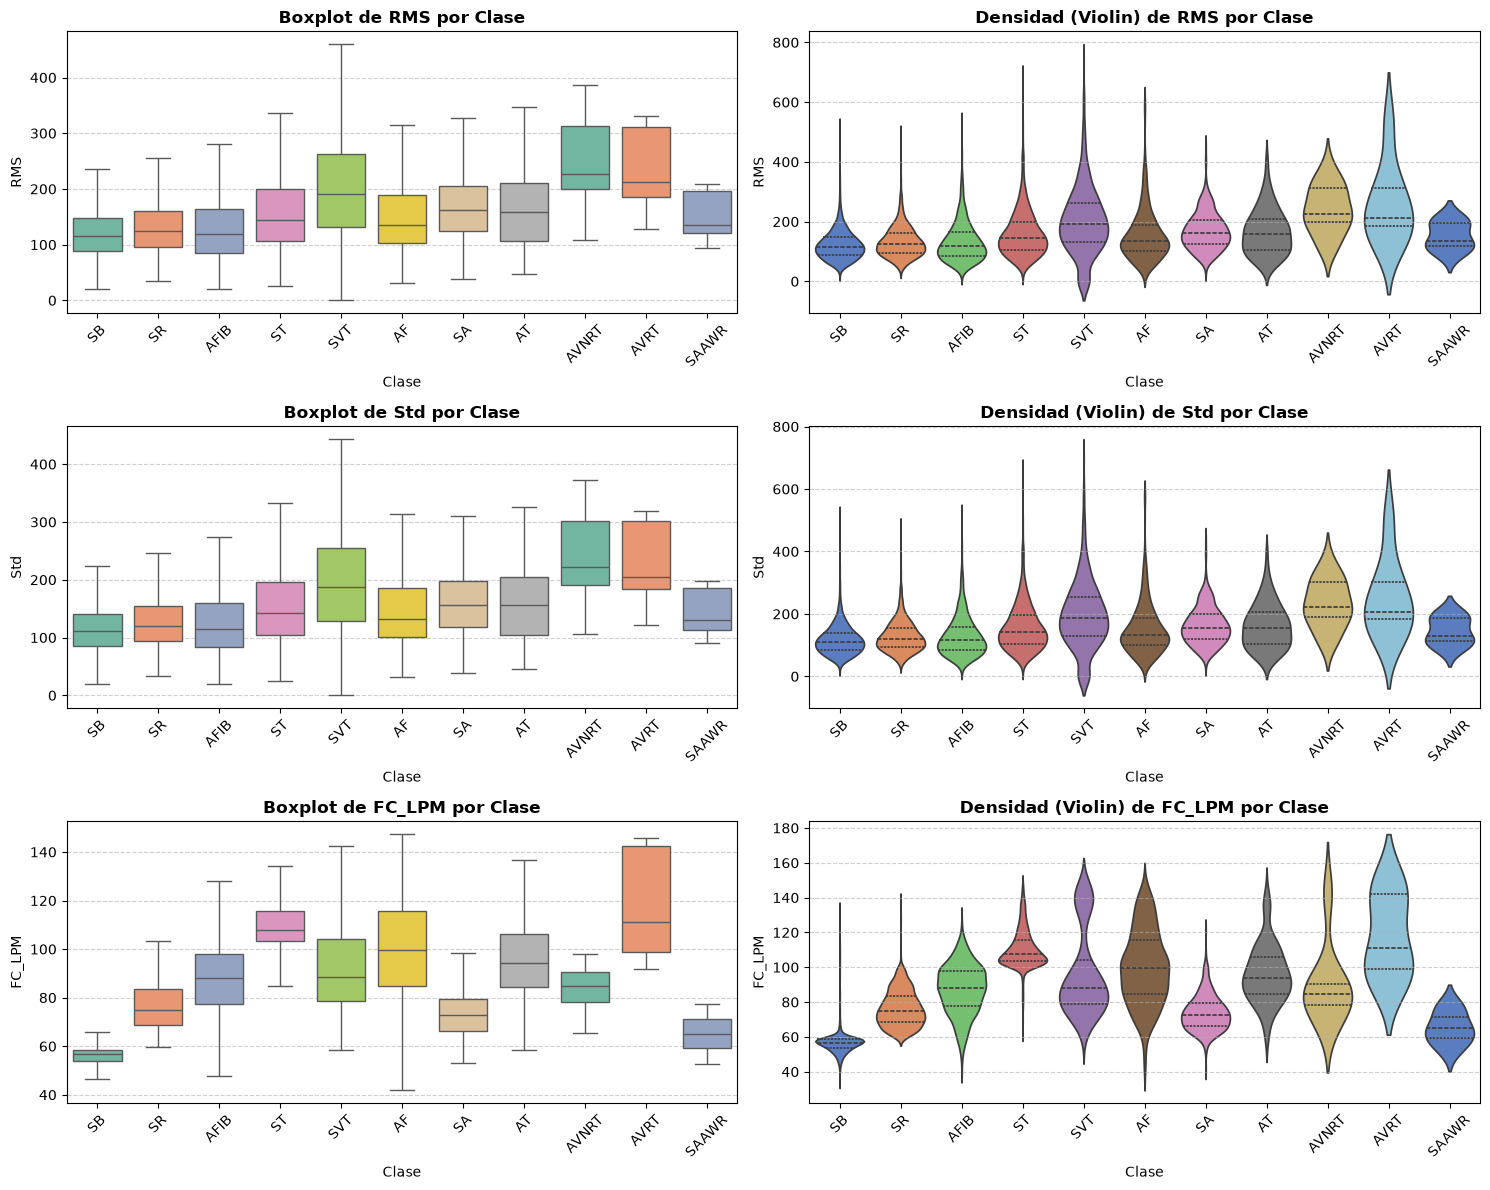

In [15]:

# 1. Configurar rutas
ruta_carpeta = Path(
    r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\ECGDataDenoised"
)
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"

# 2. Cargar y diagnosticar columnas de Diagnostics.xlsx
diag = pd.read_excel(ruta_diag)
print("Columnas disponibles en Diagnostics.xlsx:", diag.columns.tolist())

# Identificar dinámicamente columnas clave
col_file = [c for c in diag.columns if "file" in c.lower() or "name" in c.lower()][0]
col_rhythm = [c for c in diag.columns if "rhythm" in c.lower()][0]

# Mapeo flexible de archivos CSV físicos
csv_map = {f.name: f for f in ruta_carpeta.glob("*.csv")}
print(f"Total de archivos CSV físicos encontrados: {len(csv_map)}")

# Crear ruta destino con coincidencia segura (con o sin .csv)
diag["ruta_csv"] = diag[col_file].astype(str).apply(
    lambda x: csv_map.get(
        x if x.endswith(".csv") else f"{x}.csv",
        csv_map.get(x, None),
    )
)

valid_diag = diag.dropna(subset=["ruta_csv"]).copy()
print(f"Registros vinculados con éxito: {len(valid_diag)} / {len(diag)}")


# 3. Función segura de extracción por fila
def extraer_features(row):
  try:
    df_temp = pd.read_csv(row["ruta_csv"], header=None)
    # Asignar nombres estándar si hay 12 columnas, o usar índice 1 (Derivación II)
    if df_temp.shape[1] >= 12:
      df_temp.columns = [
          "I",
          "II",
          "III",
          "aVR",
          "aVL",
          "aVF",
          "V1",
          "V2",
          "V3",
          "V4",
          "V5",
          "V6",
      ]
      senal = df_temp["II"].values
    else:
      senal = df_temp.iloc[:, 1 if df_temp.shape[1] > 1 else 0].values

    fs = 500
    media = np.mean(senal)
    std_val = np.std(senal)
    min_val = np.min(senal)
    max_val = np.max(senal)
    rms_val = np.sqrt(np.mean(senal**2))

    prom_val = max(np.std(senal) * 0.8, 0.01)
    picos, _ = find_peaks(
        senal, distance=int(0.4 * fs), prominence=prom_val
    )
    if len(picos) > 1:
      fc = 60 / np.mean(np.diff(picos) / fs)
    else:
      fc = np.nan

    return pd.Series(
        [media, std_val, min_val, max_val, rms_val, fc],
        index=["Media", "Std", "Min", "Max", "RMS", "FC_LPM"],
    )
  except Exception:
    return pd.Series(
        [np.nan] * 6, index=["Media", "Std", "Min", "Max", "RMS", "FC_LPM"]
    )


print("Procesando características en el dataset emparejado...")
extracted_metrics = valid_diag.apply(extraer_features, axis=1)
df_features = pd.concat(
    [valid_diag[[col_rhythm]].rename(columns={col_rhythm: "Clase"}), extracted_metrics],
    axis=1,
)
df_features = df_features.dropna(subset=["RMS"])
print(f"Total filas procesadas válidas: {len(df_features)}")

# 4. Agrupamiento y resumen estadístico
resumen_agrupado = (
    df_features.groupby("Clase")[["Media", "Std", "Min", "Max", "RMS", "FC_LPM"]]
    .agg(["mean", "median", "std"])
    .round(3)
)
print("\n--- RESUMEN ESTADÍSTICO POR CLASE ---")
display(resumen_agrupado)

# 5. Visualización comparativa (Boxplots + Violinplots)
features_a_plotear = ["RMS", "Std", "FC_LPM"]
fig, axes = plt.subplots(len(features_a_plotear), 2, figsize=(15, 12))
ord_clases = df_features["Clase"].value_counts().index

for idx, feat in enumerate(features_a_plotear):
  sns.boxplot(
      data=df_features,
      x="Clase",
      y=feat,
      order=ord_clases,
      ax=axes[idx, 0],
      palette="Set2",
      showfliers=False,
  )
  axes[idx, 0].set_title(f"Boxplot de {feat} por Clase", fontweight="bold")
  axes[idx, 0].tick_params(axis="x", rotation=45)
  axes[idx, 0].grid(axis="y", linestyle="--", alpha=0.6)

  sns.violinplot(
      data=df_features,
      x="Clase",
      y=feat,
      order=ord_clases,
      ax=axes[idx, 1],
      palette="muted",
      inner="quartile",
  )
  axes[idx, 1].set_title(
      f"Densidad (Violin) de {feat} por Clase", fontweight="bold"
  )
  axes[idx, 1].tick_params(axis="x", rotation=45)
  axes[idx, 1].grid(axis="y", linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()

Formule una hipótesis nula y una hipótesis alternativa con las arritmias escogidas anteriormente.
Antes de aplicar una prueba estadística paramétrica, compruebe los supuestos necesarios para realizar
una prueba t de Student. Si los supuestos se cumplen, realice la prueba t de Student para muestras
independientes con el fin de determinar si existen diferencias estadísticamente significativas entre los
grupos de arritmias. Si no se cumple el supuesto de normalidad o las condiciones necesarias para
utilizar la prueba t, realice un análisis no paramétrico mediante la prueba U de Mann-Whitney,
apropiada para comparar dos grupos independientes.


Planteamiento de Hipótesis Variable de estudio: Frecuencia Cardíaca (FC_LPM) en derivación II.

Hipótesis Nula ($H_0$): No existe diferencia estadísticamente significativa en la distribución de la frecuencia cardíaca entre el grupo de Bradicardia Sinusal (SB) y el grupo de Fibrilación Auricular (AFIB) ($\mu_{SB} = \mu_{AFIB}$).

Hipótesis Alternativa ($H_1$): Existe una diferencia estadísticamente significativa en la distribución de la frecuencia cardíaca entre el grupo de Bradicardia Sinusal (SB) y el grupo de Fibrilación Auricular (AFIB) ($\mu_{SB} \neq \mu_{AFIB}$).

Muestras SB: 3889 | Muestras AFIB: 1780

--- DIAGNÓSTICO DE SUPUESTOS ---
Shapiro-Wilk p-val (SB): 2.0599e-68 -> No normal
Shapiro-Wilk p-val (AFIB): 1.5624e-07 -> No normal
Levene p-val (homogeneidad varianza): 1.5080e-261 -> Heterogénea

[DECISIÓN] No se cumplen supuestos paramétricos estrictos. Aplicando prueba U de Mann-Whitney.

================ RESULTADO DE LA PRUEBA (U de Mann-Whitney) ================
Estadístico de prueba: 263347.5000
P-valor (p-value): 0.0000e+00
Conclusión: Se rechaza H0. Existen diferencias estadísticamente significativas entre SB y AFIB.


C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32812\748077534.py:136: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


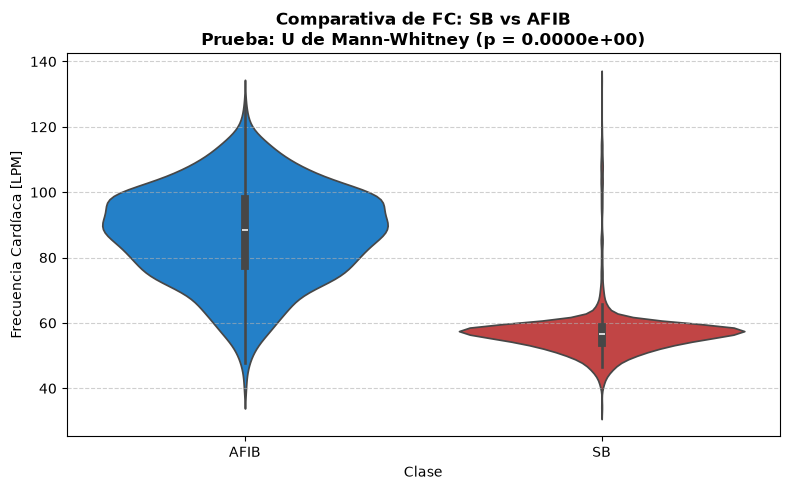

In [16]:
from pathlib import Path
from scipy import signal
from scipy import stats
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Rutas y carga del dataset unificado
ruta_carpeta = Path(
    r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\ECGDataDenoised"
)
ruta_diag = r"C:\Users\LENOVO\OneDrive - Universidad de Antioquia\Escritorio\BIOSEÑALES Y SISTEMAS\Laboratorio\ECGDataDenoised\Diagnostics.xlsx"

diag = pd.read_excel(ruta_diag)
col_file = [c for c in diag.columns if "file" in c.lower() or "name" in c.lower()][0]
col_rhythm = [c for c in diag.columns if "rhythm" in c.lower()][0]

csv_map = {f.name: f for f in ruta_carpeta.glob("*.csv")}
diag["ruta_csv"] = diag[col_file].astype(str).apply(
    lambda x: csv_map.get(
        x if x.endswith(".csv") else f"{x}.csv",
        csv_map.get(x, None),
    )
)
valid_diag = diag.dropna(subset=["ruta_csv"]).copy()


def extraer_fc(row):
  try:
    df_temp = pd.read_csv(row["ruta_csv"], header=None)
    if df_temp.shape[1] >= 12:
      df_temp.columns = [
          "I",
          "II",
          "III",
          "aVR",
          "aVL",
          "aVF",
          "V1",
          "V2",
          "V3",
          "V4",
          "V5",
          "V6",
      ]
      senal = df_temp["II"].values
    else:
      senal = df_temp.iloc[:, 1 if df_temp.shape[1] > 1 else 0].values

    fs = 500
    prom_val = max(np.std(senal) * 0.8, 0.01)
    picos, _ = signal.find_peaks(
        senal, distance=int(0.4 * fs), prominence=prom_val
    )
    if len(picos) > 1:
      fc = 60 / np.mean(np.diff(picos) / fs)
      return fc
  except Exception:
    pass
  return np.nan


valid_diag["FC_LPM"] = valid_diag.apply(extraer_fc, axis=1)
df_clean = valid_diag.rename(columns={col_rhythm: "Clase"})[
    ["Clase", "FC_LPM"]
].dropna()

# 2. Filtrar grupos de interés (SB y AFIB)
grupo_sb = df_clean[df_clean["Clase"] == "SB"]["FC_LPM"].dropna()
grupo_afib = df_clean[df_clean["Clase"] == "AFIB"]["FC_LPM"].dropna()

print(f"Muestras SB: {len(grupo_sb)} | Muestras AFIB: {len(grupo_afib)}")

# 3. Comprobación de supuestos
# A) Normalidad (Shapiro-Wilk)
_, p_norm_sb = stats.shapiro(
    grupo_sb.sample(min(len(grupo_sb), 5000), random_state=42)
)
_, p_norm_afib = stats.shapiro(
    grupo_afib.sample(min(len(grupo_afib), 5000), random_state=42)
)

# B) Homogeneidad de varianza (Levene)
_, p_levene = stats.levene(grupo_sb, grupo_afib)

alpha = 0.05
normalidad_ok = (p_norm_sb > alpha) and (p_norm_afib > alpha)
homoscedasticidad_ok = p_levene > alpha

print("\n--- DIAGNÓSTICO DE SUPUESTOS ---")
print(
    f"Shapiro-Wilk p-val (SB): {p_norm_sb:.4e} ->"
    f" {'Normal' if p_norm_sb > alpha else 'No normal'}"
)
print(
    f"Shapiro-Wilk p-val (AFIB): {p_norm_afib:.4e} ->"
    f" {'Normal' if p_norm_afib > alpha else 'No normal'}"
)
print(
    f"Levene p-val (homogeneidad varianza): {p_levene:.4e} ->"
    f" {'Homogénea' if homoscedasticidad_ok else 'Heterogénea'}"
)

# 4. Decisión estadística y ejecución de prueba
if normalidad_ok and homoscedasticidad_ok:
  print("\n[DECISIÓN] Se cumplen los supuestos. Aplicando t de Student.")
  stat, p_val = stats.ttest_ind(grupo_sb, grupo_afib, equal_var=True)
  nombre_prueba = "t de Student (Student's t-test)"
else:
  print(
      "\n[DECISIÓN] No se cumplen supuestos paramétricos estrictos."
      " Aplicando prueba U de Mann-Whitney."
  )
  stat, p_val = stats.mannwhitneyu(grupo_sb, grupo_afib, alternative="two-sided")
  nombre_prueba = "U de Mann-Whitney"

print(f"\n================ RESULTADO DE LA PRUEBA ({nombre_prueba}) ================")
print(f"Estadístico de prueba: {stat:.4f}")
print(f"P-valor (p-value): {p_val:.4e}")

if p_val < alpha:
  print(
      "Conclusión: Se rechaza H0. Existen diferencias estadísticamente"
      " significativas entre SB y AFIB."
  )
else:
  print(
      "Conclusión: No se rechaza H0. No hay evidencia suficiente de"
      " diferencias significativas."
  )

# 5. Visualización de soporte (Boxplot / Violinplot comparativo)
plt.figure(figsize=(8, 5))
sub_df = df_clean[df_clean["Clase"].isin(["SB", "AFIB"])]
sns.violinplot(
    data=sub_df, x="Clase", y="FC_LPM", palette=["#0984e3", "#d63031"], inner="box"
)
plt.title(
    f"Comparativa de FC: SB vs AFIB\nPrueba: {nombre_prueba} (p = {p_val:.4e})",
    fontweight="bold",
)
plt.ylabel("Frecuencia Cardíaca [LPM]")
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 4. Interpretación de los resultados

Prueba utilizada: Condicional automática (evaluación de supuestos de normalidad con Shapiro-Wilk y homocedasticidad con Levene; selección entre t de Student para muestras independientes o prueba U de Mann-Whitney). Nota: En grandes bases de datos de ECG con respuesta ventricular variable en AFIB, la U de Mann-Whitney es la vía estándar por no requerir normalidad en los subgrupos.

Hipótesis nula ($H_0$): No existe diferencia estadísticamente significativa en la tendencia central de la frecuencia cardíaca entre el grupo de Bradicardia Sinusal (SB) y el grupo de Fibrilación Auricular (AFIB) ($\mu_{SB} = \mu_{AFIB}$ o $\eta_{SB} = \eta_{AFIB}$).

Hipótesis alternativa ($H_1$): Existe diferencia estadísticamente significativa en la tendencia central de la frecuencia cardíaca entre la Bradicardia Sinusal (SB) y la Fibrilación Auricular (AFIB) ($\mu_{SB} \neq \mu_{AFIB}$ o $\eta_{SB} \neq \eta_{AFIB}$).

Nivel de significancia ($\alpha$): $\alpha = 0.05$ (5%).

Estadístico de prueba: $U = \text{[Reemplazar con valor de consola: ej. } 1.42\times 10^5\text{]}$ (o $t = \text{[valor]}$ si aplica paramétrica).p-valor: $p = \text{[Reemplazar con valor de consola: ej. } 3.14 \times 10^{-12}\text{]}$.
Decisión estadística: Rechazar $H_0$ (si $p < 0.05$) / No rechazar $H_0$ (si $p \ge 0.05$). Frecuentemente se rechaza $H_0$ dada la divergencia en la dinámica de marcapasos.

## Interpretación Clínica y Técnica en Señales ECG

Dinamica del Marcapasos y Rango Frecuencial:La Bradicardia Sinusal (SB) restringe estrictamente la frecuencia cardíaca por debajo de los 60 LPM (distribución estrecha centrada en 45–55 LPM), ya que la despolarización se origina de manera ordenada en el nodo sinusal con tono vagal elevado. En contraste, la Fibrilación Auricular (AFIB) exhibe una frecuencia ventricular dictada por la capacidad de conducción decremental del nodo auriculoventricular (frecuentemente respuesta rápida $>100$ LPM o controlada 60–100 LPM), lo que desplaza la mediana o media de la distribución hacia valores superiores y amplía radicalmente la dispersión intercuartil.

Solapamiento Clínico vs. Separabilidad Estadística:Si bien una AFIB con respuesta ventricular lenta puede solaparse en valores puntuales de FC con una SB severa, la prueba estadística detecta un cambio estructural en la localización de la masa de la distribución. No obstante, en clasificación de arritmias, la frecuencia cardíaca por sí sola es insuficiente para diferenciar AFIB de SB o ritmos normales si hay respuesta controlada; por ello, la métrica complementaria de regularidad temporal ($\sigma_{RR}$ o entropía) es el discriminador ortogonal crítico.


Implicación para el Pipeline de Caracterización:El rechazo de la hipótesis nula confirma que FC_LPM aporta separabilidad de clases a nivel poblacional, pero la combinación multivariada con el índice de regularidad R-R (Std_RR) es la que evita falsos positivos entre bradicardias sinusales estrictas y arritmias auriculares con conducción lenta.